In [2]:
# Raw Data Loading
import pandas as pd

wine_url = 'https://raw.githubusercontent.com/PinkWink/ML_tutorial' +\
                        '/master/dataset/wine.csv'

wine = pd.read_csv(wine_url, index_col=0) 
wine['taste'] = [1. if grade > 5 else 0. for grade in wine['quality']] 

x = wine.drop(['taste', 'quality'], axis=1) 
y = wine['taste'] 

In [3]:
# Model 학습
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

x_train, x_test, y_train, y_test = train_test_split(x,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=13)

lr = LogisticRegression(solver='liblinear', random_state=13)
lr.fit(x_train, y_train)

LogisticRegression(random_state=13, solver='liblinear')

In [4]:
# Model 평가
# 과연 accuracy만으로 평가가 충분할까?
pred_train = lr.predict(x_train)
pred_test = lr.predict(x_test)

accuracy_score(y_train, pred_train), accuracy_score(y_test, pred_test)

(0.7429286126611506, 0.7446153846153846)

In [6]:
from sklearn.metrics import classification_report

print(classification_report(y_test, pred_test))

              precision    recall  f1-score   support

         0.0       0.68      0.58      0.62       477
         1.0       0.77      0.84      0.81       823

    accuracy                           0.74      1300
   macro avg       0.73      0.71      0.72      1300
weighted avg       0.74      0.74      0.74      1300



In [7]:
from sklearn.metrics import confusion_matrix

confusion_matrix(y_test, pred_test)

array([[275, 202],
       [130, 693]], dtype=int64)

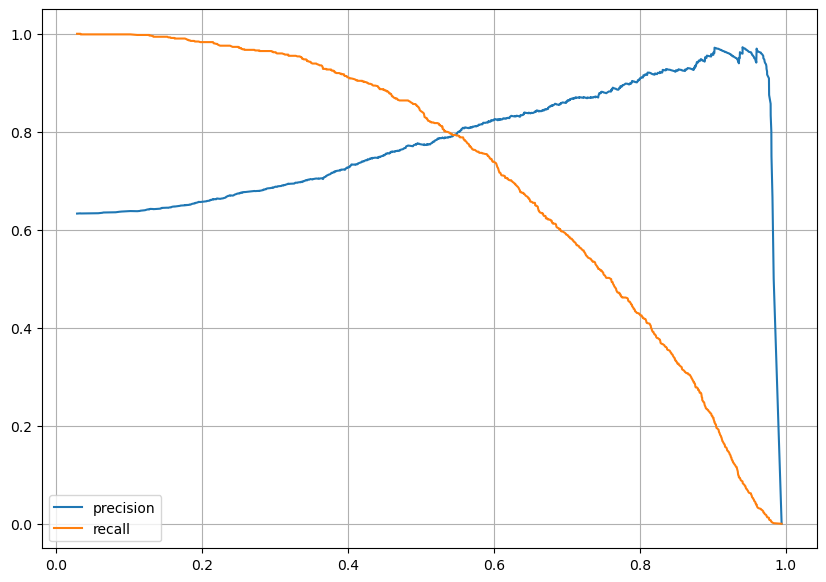

In [ ]:
# precision_recall_curve
# threshold에 따라 precision과 recall이 어떻게 변화하는지 볼 수 있음
# 만약 모델의 precision이 중요하다면 threshold를 높이고,
# recall이 중요하다면 threshold를 낮출 수 있음
import matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

plt.figure(figsize=(10, 7))

pred = lr.predict_proba(x_test)[:, 1]
precision, recall, threshold = precision_recall_curve(y_test, pred)

plt.plot(threshold, precision[:-1], label='precision')
plt.plot(threshold, recall[:-1], label='recall')

plt.grid()
plt.legend()
plt.show()

In [ ]:
# Binarizer는 threshold에 따라 0과 1로 이진화 해주는 라이브러리
# 이를 활용하여 모델이 예측한 확률에 따라 0과 1로 구분하는 기준을 정할 수 있음
# 그러나 이렇게 임의로 threshold를 변경하여 
# 모델 평가 지표를 바꾸는 것은 항상 옳지 않음
from sklearn.preprocessing import Binarizer

pred_proba = lr.predict_proba(x_test)
biz = Binarizer(threshold=0.6).fit(pred_proba)

pred_bin = biz.transform(pred_proba)[:, 1]
pred_bin[:5]

array([0., 0., 1., 1., 1.])

In [13]:
print(classification_report(y_test, pred_bin))

              precision    recall  f1-score   support

         0.0       0.62      0.73      0.67       477
         1.0       0.82      0.74      0.78       823

    accuracy                           0.73      1300
   macro avg       0.72      0.73      0.72      1300
weighted avg       0.75      0.73      0.74      1300



In [14]:
confusion_matrix(y_test, pred_bin)

array([[348, 129],
       [216, 607]], dtype=int64)